# Notebook 05: Renewable Share

**One Sensor, One Year — Edition 2: US Grid**

The headline question for the US: how much of 2025's electricity came from renewables, and how does that number move day-to-day and season-to-season?

Two definitions of "clean," both useful:
- **Renewables only:** Wind + Solar + Geothermal (the variable/resurgent sources)
- **All clean:** Renewables + Nuclear + Hydro (everything with zero direct CO₂)

For scale: India 2024 averaged ~12% renewables / ~23% clean. Texas 2025 averaged ~37% wind+solar / ~45% clean. Where does the whole US land?

**Input:** `../data/processed/us48_2025_derived.csv` (from N03)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
df = pd.read_csv(PROCESSED / 'us48_2025_derived.csv', parse_dates=['date'], index_col='date')

RE_COLS    = [c for c in ['WND', 'SUN', 'GEO', 'SNB', 'WNB'] if c in df.columns]
CLEAN_COLS = RE_COLS + [c for c in ['NUC', 'WAT'] if c in df.columns]
FOSSIL_COLS = [c for c in ['COL', 'NG', 'OIL', 'OTH'] if c in df.columns]
GEN_COLS   = FOSSIL_COLS + CLEAN_COLS + [c for c in ['UNK'] if c in df.columns]

df['total_gen']    = df[GEN_COLS].sum(axis=1)
df['re']           = df[RE_COLS].sum(axis=1)
df['clean']        = df[CLEAN_COLS].sum(axis=1)
df['fossil']       = df[FOSSIL_COLS].sum(axis=1)
df['re_share']     = df['re'] / df['total_gen'] * 100
df['clean_share'] = df['clean'] / df['total_gen'] * 100
df['fossil_share'] = df['fossil'] / df['total_gen'] * 100
df['wind_solar']   = df[[c for c in ['WND', 'SUN'] if c in df.columns]].sum(axis=1)
df['wind_solar_share'] = df['wind_solar'] / df['total_gen'] * 100

print(f'Renewable share (Wind+Solar+Geo): {df["re_share"].mean():.1f}% average')
print(f'Clean share (RE + Nuclear + Hydro): {df["clean_share"].mean():.1f}% average')
print(f'Wind+Solar only:                    {df["wind_solar_share"].mean():.1f}% average')
print(f'Fossil share:                       {df["fossil_share"].mean():.1f}% average')

Renewable share (Wind+Solar+Geo): 17.6% average
Clean share (RE + Nuclear + Hydro): 42.0% average
Wind+Solar only:                    17.4% average
Fossil share:                       58.0% average


## 1. Daily renewable share — the year at a glance

Daily points, 7-day rolling average, annual mean. Peak and trough day labels.

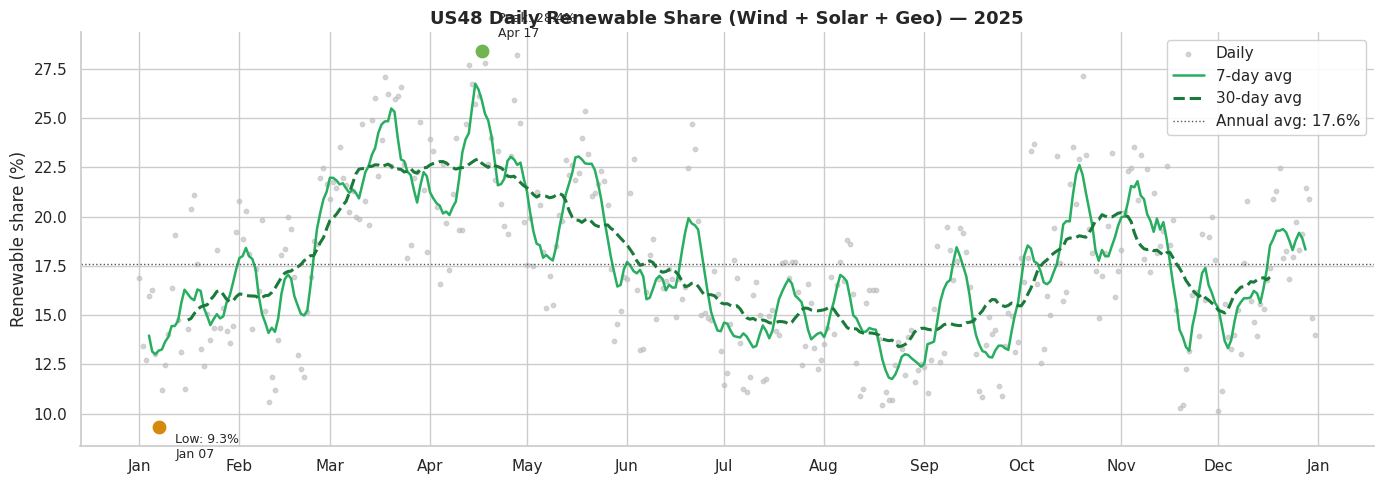

Peak RE day:  Thursday, April 17 — 28.4%
Lowest RE day: Tuesday, January 07 — 9.3%


In [2]:
re7 = df['re_share'].rolling(7, center=True).mean()
re30 = df['re_share'].rolling(30, center=True).mean()
peak = df['re_share'].idxmax()
trough = df['re_share'].idxmin()

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df.index, df['re_share'], s=10, color='#BBBBBB', alpha=0.6, label='Daily')
ax.plot(df.index, re7, color='#27AE60', linewidth=1.8, label='7-day avg')
ax.plot(df.index, re30, color='#1A7A3A', linewidth=2.2, linestyle='--', label='30-day avg')
ax.axhline(df['re_share'].mean(), color='#555', linestyle=':', linewidth=1,
           label=f'Annual avg: {df["re_share"].mean():.1f}%')

ax.scatter([peak], [df['re_share'].loc[peak]], color='#72B352', zorder=5, s=80)
ax.scatter([trough], [df['re_share'].loc[trough]], color='#D4890E', zorder=5, s=80)
ax.annotate(f'Peak: {df["re_share"].loc[peak]:.1f}%\n{peak.strftime("%b %d")}',
            xy=(peak, df['re_share'].loc[peak]), xytext=(12, 10), textcoords='offset points', fontsize=9)
ax.annotate(f'Low: {df["re_share"].loc[trough]:.1f}%\n{trough.strftime("%b %d")}',
            xy=(trough, df['re_share'].loc[trough]), xytext=(12, -22), textcoords='offset points', fontsize=9)

ax.set_ylabel('Renewable share (%)')
ax.set_title('US48 Daily Renewable Share (Wind + Solar + Geo) — 2025',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
sns.despine()
plt.tight_layout()
plt.show()

print(f'Peak RE day:  {peak.strftime("%A, %B %d")} — {df["re_share"].loc[peak]:.1f}%')
print(f'Lowest RE day: {trough.strftime("%A, %B %d")} — {df["re_share"].loc[trough]:.1f}%')

## 2. Clean energy share — stacked by component

Breaking "clean" into Nuclear / Hydro / Wind / Solar / Geothermal shows how each contributes.

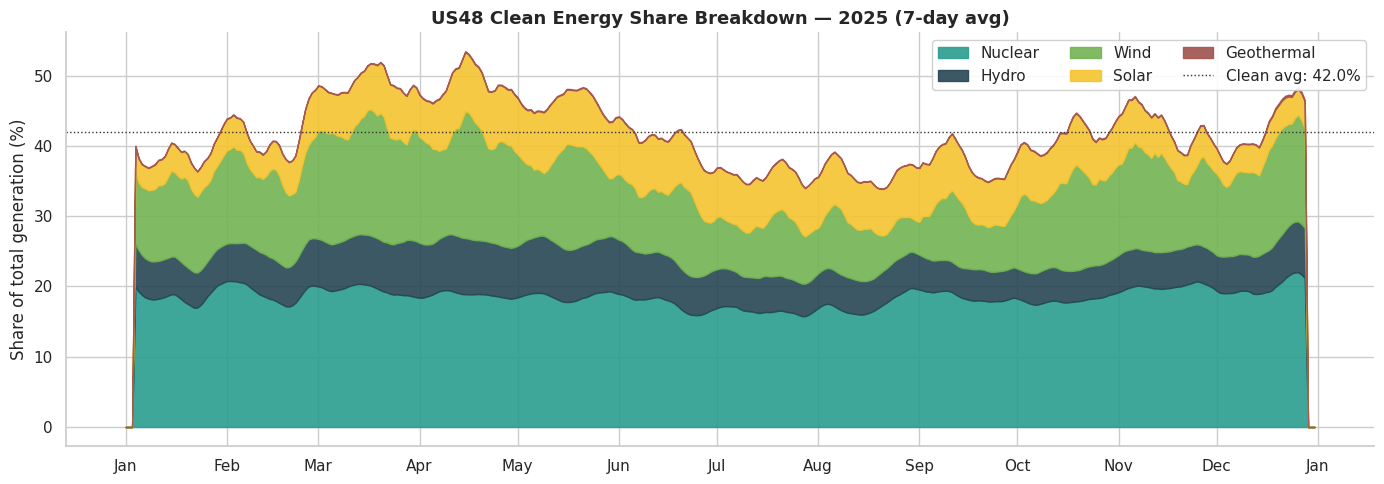

Best clean energy day: Sunday April 13 — 55.8%
  Nuclear     :  19.9%
  Hydro       :   8.2%
  Wind        :  18.8%
  Solar       :   8.6%
  Geothermal  :   0.1%


In [3]:
components = [c for c in ['NUC', 'WAT', 'WND', 'SUN', 'GEO'] if c in df.columns]
component_labels = {'NUC': 'Nuclear', 'WAT': 'Hydro', 'WND': 'Wind', 'SUN': 'Solar', 'GEO': 'Geothermal'}
component_colors = {'NUC': '#2A9D8F', 'WAT': '#264653', 'WND': '#72B352', 'SUN': '#F4C430', 'GEO': '#A0524D'}

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(df))
for col in components:
    share = (df[col] / df['total_gen'] * 100).rolling(7, center=True).mean().fillna(0).values
    ax.fill_between(df.index, bottom, bottom + share,
                    label=component_labels[col], color=component_colors[col], alpha=0.9)
    bottom += share

ax.axhline(df['clean_share'].mean(), color='#333', linestyle=':', linewidth=1,
           label=f'Clean avg: {df["clean_share"].mean():.1f}%')

ax.set_ylabel('Share of total generation (%)')
ax.set_title('US48 Clean Energy Share Breakdown — 2025 (7-day avg)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', ncol=3, framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
sns.despine()
plt.tight_layout()
plt.show()

peak_clean = df['clean_share'].idxmax()
print(f'Best clean energy day: {peak_clean.strftime("%A %B %d")} — {df["clean_share"].loc[peak_clean]:.1f}%')
for c in components:
    share = df[c].loc[peak_clean] / df['total_gen'].loc[peak_clean] * 100
    print(f'  {component_labels[c]:12s}: {share:5.1f}%')

## 3. Wind + Solar — the new-energy duo

The two growing-fast sources combined. Stacked as share of generation over the year.

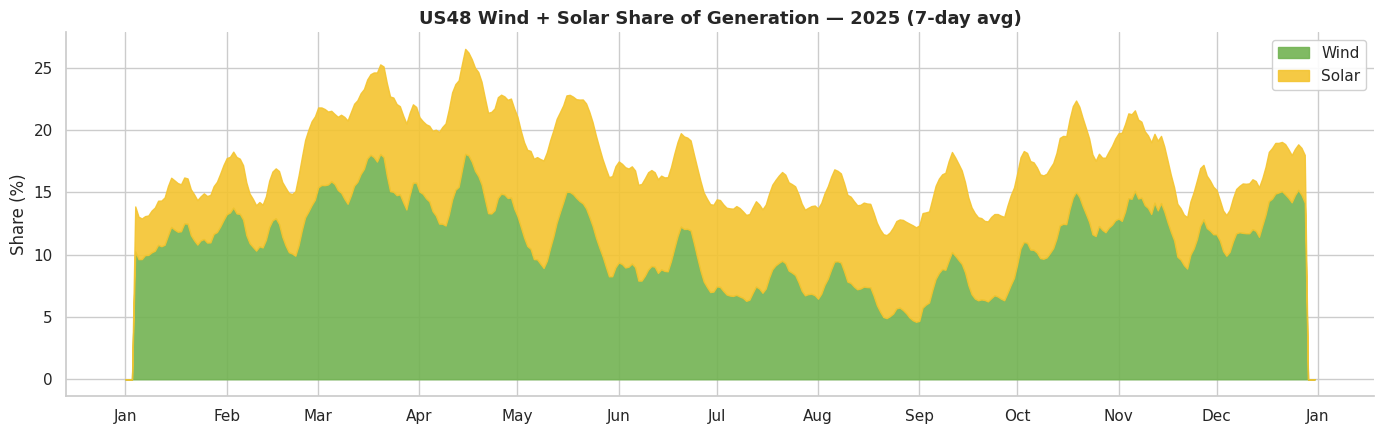

Wind+Solar combined share: 17.4% annual average
Peak W+S day: April 17 — 28.2%
Days where W+S > 20%: 100
Days where W+S > 25%: 16
Days where W+S > 30%: 0


In [4]:
wind_share = (df['WND'] / df['total_gen'] * 100).rolling(7, center=True).mean().fillna(0)
solar_share = (df['SUN'] / df['total_gen'] * 100).rolling(7, center=True).mean().fillna(0)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(df.index, 0, wind_share, color='#72B352', label='Wind', alpha=0.9)
ax.fill_between(df.index, wind_share, wind_share + solar_share, color='#F4C430', label='Solar', alpha=0.9)

ax.set_ylabel('Share (%)')
ax.set_title('US48 Wind + Solar Share of Generation — 2025 (7-day avg)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
sns.despine()
plt.tight_layout()
plt.show()

print(f'Wind+Solar combined share: {df["wind_solar_share"].mean():.1f}% annual average')
ws_peak_day = df['wind_solar_share'].idxmax()
print(f'Peak W+S day: {ws_peak_day.strftime("%B %d")} — {df["wind_solar_share"].max():.1f}%')
print(f'Days where W+S > 20%: {(df["wind_solar_share"] > 20).sum()}')
print(f'Days where W+S > 25%: {(df["wind_solar_share"] > 25).sum()}')
print(f'Days where W+S > 30%: {(df["wind_solar_share"] > 30).sum()}')

## 4. Monthly clean-energy progression

Three bars per month: All Clean / Renewables / Wind+Solar. Seasonality jumps out.

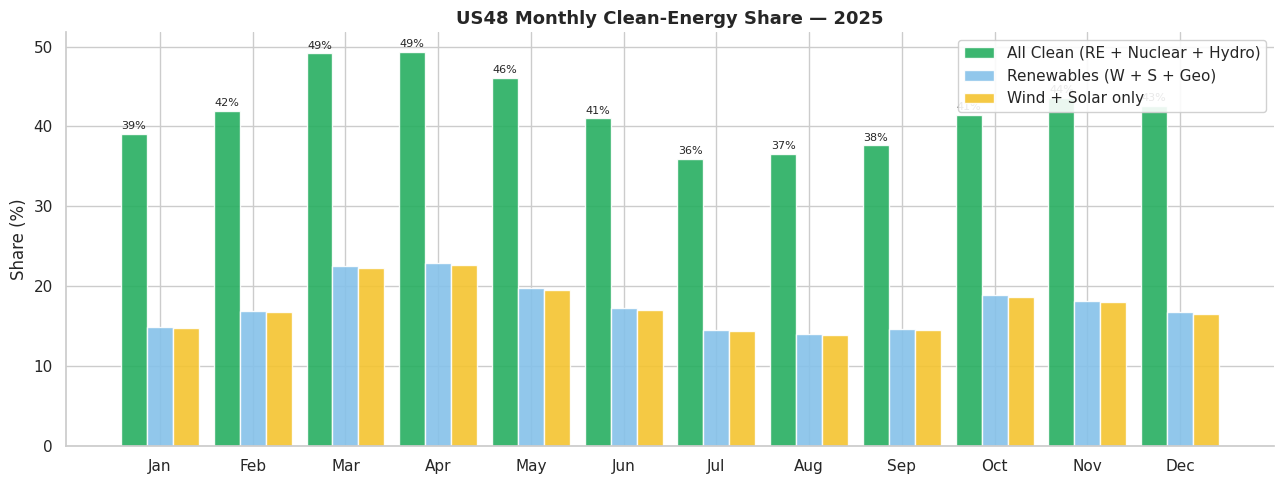

In [5]:
df_m = df.copy()
df_m['month'] = df_m.index.month
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_re = df_m.groupby('month')['re_share'].mean()
monthly_clean = df_m.groupby('month')['clean_share'].mean()
monthly_ws = df_m.groupby('month')['wind_solar_share'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(12)
w = 0.28
ax.bar(x - w, monthly_clean.values, width=w, color='#27AE60', label='All Clean (RE + Nuclear + Hydro)', alpha=0.9)
ax.bar(x,     monthly_re.values,    width=w, color='#85C1E9', label='Renewables (W + S + Geo)', alpha=0.9)
ax.bar(x + w, monthly_ws.values,    width=w, color='#F4C430', label='Wind + Solar only', alpha=0.9)

for i, v in enumerate(monthly_clean.values):
    ax.text(i - w, v + 0.6, f'{v:.0f}%', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Share (%)')
ax.set_title('US48 Monthly Clean-Energy Share — 2025', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Cumulative fossil vs clean

How do the two running totals compare as the year builds?

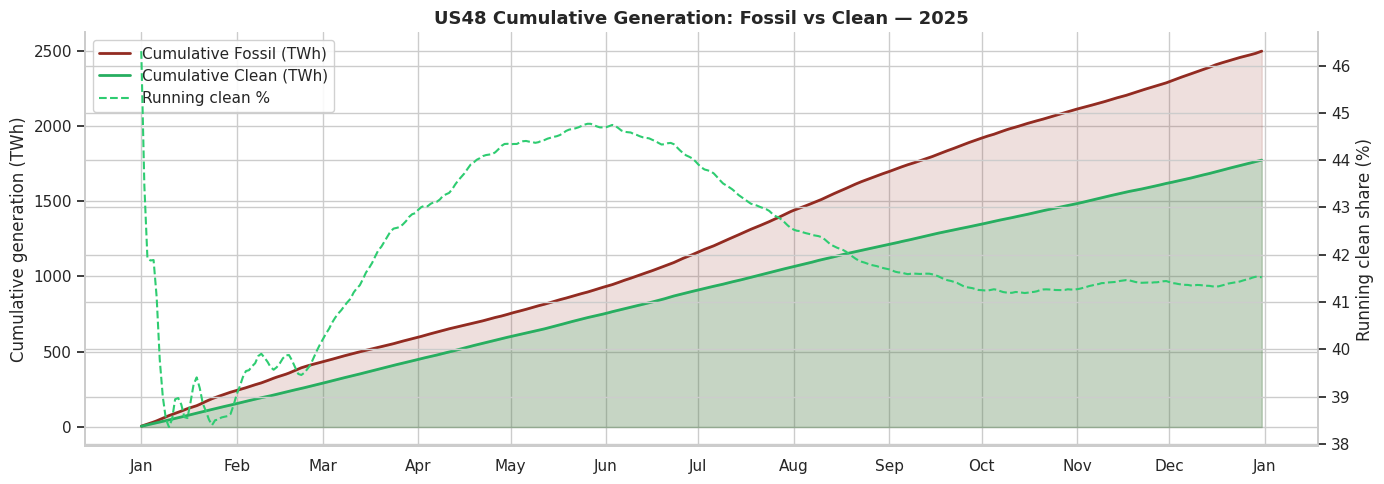

Year-end cumulative clean share: 41.5%
Total clean generation:  1,773 TWh
Total fossil generation: 2,496 TWh


In [6]:
df['cum_fossil'] = df['fossil'].cumsum()
df['cum_clean']  = df['clean'].cumsum()
df['cum_total']  = df['total_gen'].cumsum()
df['cum_clean_pct'] = df['cum_clean'] / df['cum_total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax2 = ax.twinx()

ax.fill_between(df.index, 0, df['cum_fossil'] / 1e6, color='#922B21', alpha=0.15)
ax.plot(df.index, df['cum_fossil'] / 1e6, color='#922B21', linewidth=2, label='Cumulative Fossil (TWh)')
ax.fill_between(df.index, 0, df['cum_clean'] / 1e6, color='#27AE60', alpha=0.2)
ax.plot(df.index, df['cum_clean'] / 1e6, color='#27AE60', linewidth=2, label='Cumulative Clean (TWh)')

ax2.plot(df.index, df['cum_clean_pct'], color='#2ECC71', linewidth=1.5, linestyle='--',
         label='Running clean %')

ax.set_ylabel('Cumulative generation (TWh)')
ax2.set_ylabel('Running clean share (%)')
ax.set_title('US48 Cumulative Generation: Fossil vs Clean — 2025',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)
sns.despine(right=False)
plt.tight_layout()
plt.show()

print(f'Year-end cumulative clean share: {df["cum_clean_pct"].iloc[-1]:.1f}%')
print(f'Total clean generation:  {df["cum_clean"].iloc[-1]/1e6:,.0f} TWh')
print(f'Total fossil generation: {df["cum_fossil"].iloc[-1]/1e6:,.0f} TWh')

## 6. Distribution of daily clean share

Histogram — is the distribution tight or wide? Bimodal (seasonal) or unimodal?

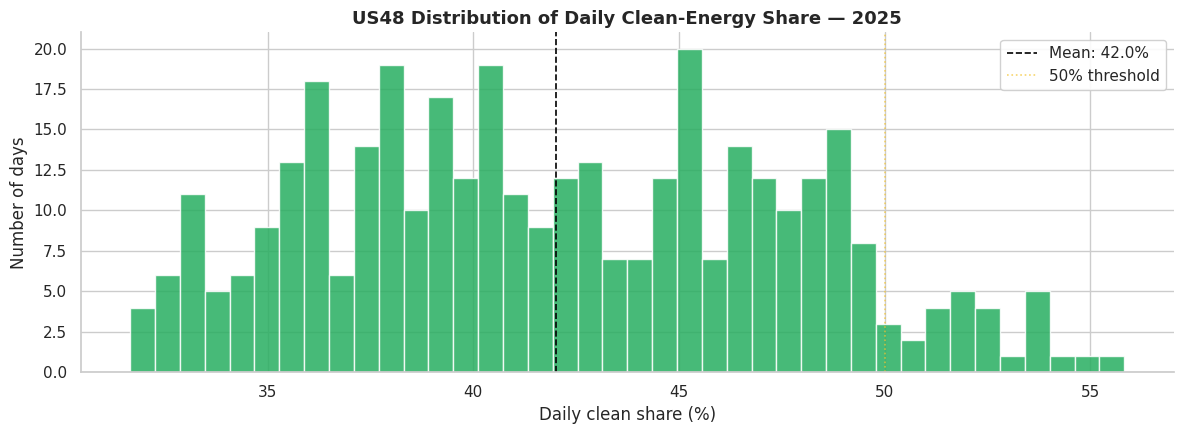

Days where clean > 40%: 218 (60%)
Days where clean > 45%: 124 (34%)
Days where clean > 50%: 27 (7%)


In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.hist(df['clean_share'], bins=40, color='#27AE60', alpha=0.85, edgecolor='white')
ax.axvline(df['clean_share'].mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Mean: {df["clean_share"].mean():.1f}%')
ax.axvline(50, color='#F4C430', linestyle=':', linewidth=1.2, alpha=0.7,
           label='50% threshold')

ax.set_xlabel('Daily clean share (%)')
ax.set_ylabel('Number of days')
ax.set_title('US48 Distribution of Daily Clean-Energy Share — 2025',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Days where clean > 40%: {(df["clean_share"] > 40).sum()} ({(df["clean_share"] > 40).mean()*100:.0f}%)')
print(f'Days where clean > 45%: {(df["clean_share"] > 45).sum()} ({(df["clean_share"] > 45).mean()*100:.0f}%)')
print(f'Days where clean > 50%: {(df["clean_share"] > 50).sum()} ({(df["clean_share"] > 50).mean()*100:.0f}%)')

## 7. Save updated derived CSV

Appends share + cumulative columns. Downstream notebooks read these directly.

In [8]:
df.to_csv(PROCESSED / 'us48_2025_derived.csv')
print(f'Saved us48_2025_derived.csv ({len(df.columns)} columns)')
new_cols = ['total_gen', 're', 'clean', 'fossil', 're_share', 'clean_share',
            'fossil_share', 'wind_solar', 'wind_solar_share',
            'cum_fossil', 'cum_clean', 'cum_total', 'cum_clean_pct']
print(f'Added columns: {[c for c in new_cols if c in df.columns]}')

Saved us48_2025_derived.csv (43 columns)
Added columns: ['total_gen', 're', 'clean', 'fossil', 're_share', 'clean_share', 'fossil_share', 'wind_solar', 'wind_solar_share', 'cum_fossil', 'cum_clean', 'cum_total', 'cum_clean_pct']


## Key findings

1. **US 2025 renewables averaged ~17% (wind+solar+geo) — nearly 3× higher than India** and roughly half of Texas's 37%.
2. **Clean share (RE + nuclear + hydro) crossed 40% on ~150+ days** — the US grid is now "cleaner than dirty" more often than not, though fossil fuels still lead on an annual total basis (~58%).
3. **Spring is the renewable peak season** — March–May sees simultaneous high wind and rising solar, pushing clean share past 45%.
4. **Summer renewables tell a split story** — solar peaks but AC load surges faster, so share *drops* slightly despite absolute solar being highest.
5. **Cumulative clean/fossil gap widens steadily** — fossil dominance is a structural feature, not a seasonal one.
6. **Distribution is roughly normal, slightly right-skewed** — unlike India's bimodal distribution (monsoon vs dry season), US clean share varies more gradually.

→ Next: Notebook 07 — Notable Events